In [33]:
import os
import numpy as np
from pathlib import Path
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

## 1. Load and Preprocess Data

In [ ]:


# ---- Config ----
DATA_DIR = Path("MP_Videos_All_keyframes/")   # your collected keypoints live here
SEQ_LEN  = 60                # frames per sequence expected by the LSTM
SAVE_DIR = Path("artifacts_6_classes") # where to persist preprocessed arrays
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ---- Discover action classes from directory names ----
places: List[str] = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
if not places:
    raise RuntimeError(f"No action folders found in {DATA_DIR.resolve()}")
print("Detected places:", places)


Detected places: ['Bedok', 'City Hall', 'Clementi', 'Esplanade', 'MBS', 'Orchard']


## 2. Prepare Training and Testing Data

In [36]:
# ---- Helpers ----
def load_sequence(seq_dir: Path, expected_len: int = SEQ_LEN) -> np.ndarray:
    """
    Load all .npy frames in a sequence folder, sort by filename, and
    pad/truncate to expected_len. Each frame must be a 1D vector (e.g. 1662,).
    Returns shape: (expected_len, F) float32.
    """
    frame_files = sorted([p for p in seq_dir.iterdir() if p.suffix == ".npy"])
    frames = []
    for f in frame_files[:expected_len]:
        arr = np.load(f)
        if arr.ndim != 1:
            raise ValueError(f"Frame {f} has shape {arr.shape}; expected (F,)")
        frames.append(arr.astype(np.float32, copy=False))
    # infer feature dim (F)
    if frames:
        F = frames[0].shape[0]
    else:
        # If the sequence folder is empty, fall back to 1662 (your legacy size)
        F = 1662
    # pad if too short
    if len(frames) < expected_len:
        pad = [np.zeros((F,), dtype=np.float32) for _ in range(expected_len - len(frames))]
        frames.extend(pad)
    # truncate if too long
    frames = frames[:expected_len]
    seq = np.stack(frames, axis=0)  # (T, F)
    return seq

def iter_sequences(data_root: Path) -> Tuple[List[np.ndarray], List[str]]:
    X_list, y_list = [], []
    for action in actions:
        action_dir = data_root / action
        # sequence folders under each action (e.g., "0", "1", ...)
        seq_dirs = sorted([p for p in action_dir.iterdir() if p.is_dir()],
                          key=lambda p: p.name)
        for sd in seq_dirs:
            try:
                seq = load_sequence(sd, SEQ_LEN)
                # sanity: finite values only
                if not np.isfinite(seq).all():
                    continue
                X_list.append(seq)
                y_list.append(action)
            except Exception as e:
                # Skip corrupted sequences but continue
                print(f"[WARN] Skipping {sd}: {e}")
    return X_list, y_list

# ---- Load all sequences ----
X_list, y_list = iter_sequences(DATA_DIR)
if not X_list:
    raise RuntimeError("No valid sequences found. Check your data folders.")

X = np.stack(X_list, axis=0).astype(np.float32)  # (N, T, F)
print("X shape:", X.shape)

# ---- Encode labels (int -> one-hot) ----
le = LabelEncoder()
y_int = le.fit_transform(y_list)                       # (N,)
num_classes = len(le.classes_)
y = tf.keras.utils.to_categorical(y_int, num_classes)  # (N, C)
print("Classes:", list(le.classes_))
print("y (one-hot) shape:", y.shape)

# ---- Stratified train/val/test split (80/10/10) ----
X_train, X_tmp, y_train, y_tmp, yi_train, yi_tmp = train_test_split(
    X, y, y_int, test_size=0.20, random_state=42, stratify=y_int
)
X_val, X_test, y_val, y_test, yi_val, yi_test = train_test_split(
    X_tmp, y_tmp, yi_tmp, test_size=0.50, random_state=42, stratify=yi_tmp
)

print(
    f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape} | "
    f"Classes={num_classes}"
)

# ---- Optional: class distribution report ----
def dist(name, yi):
    unique, counts = np.unique(yi, return_counts=True)
    print(name, dict(zip(le.inverse_transform(unique), counts.tolist())))

dist("Train dist:", yi_train)
dist("Val   dist:", yi_val)
dist("Test  dist:", yi_test)

# ---- Persist for later sections ----
np.savez_compressed(SAVE_DIR / "dataset_train.npz", X=X_train, y=y_train)
np.savez_compressed(SAVE_DIR / "dataset_val.npz",   X=X_val,   y=y_val)
np.savez_compressed(SAVE_DIR / "dataset_test.npz",  X=X_test,  y=y_test)

# ---- Handy accessors if you prefer variables in-memory for the next cell ----
classes = le.classes_.tolist()
feature_dim = X.shape[-1]
print("classes:", classes)
print("feature_dim:", feature_dim)


X shape: (180, 60, 258)
Classes: ['Bedok', 'City Hall', 'Clementi', 'Esplanade', 'MBS', 'Orchard']
y (one-hot) shape: (180, 6)
Train: (144, 60, 258), Val: (18, 60, 258), Test: (18, 60, 258) | Classes=6
Train dist: {'Bedok': 24, 'City Hall': 24, 'Clementi': 24, 'Esplanade': 24, 'MBS': 24, 'Orchard': 24}
Val   dist: {'Bedok': 3, 'City Hall': 3, 'Clementi': 3, 'Esplanade': 3, 'MBS': 3, 'Orchard': 3}
Test  dist: {'Bedok': 3, 'City Hall': 3, 'Clementi': 3, 'Esplanade': 3, 'MBS': 3, 'Orchard': 3}
classes: ['Bedok', 'City Hall', 'Clementi', 'Esplanade', 'MBS', 'Orchard']
feature_dim: 258


## 3. LSTM Training

In [ ]:

ARTIFACTS = Path("artifacts_6_classes"); ARTIFACTS.mkdir(parents=True, exist_ok=True)

# TensorBoard logs directory (timestamped run folder)
from datetime import datetime
TB_ROOT = ARTIFACTS / "tb_logs" / "train"
TB_ROOT.mkdir(parents=True, exist_ok=True)
LOG_DIR = TB_ROOT / datetime.now().strftime("%Y%m%d-%H%M%S")

seq_len, feature_dim = int(X_train.shape[1]), int(X_train.shape[2])
num_classes = int(y_train.shape[1])
assert num_classes >= 2, "Need at least 2 classes."

# --- sample weights (class balancing) ---
yi_train = np.argmax(y_train, axis=1)
counts = np.bincount(yi_train, minlength=num_classes).astype(np.float64)
inv_freq = (counts.sum() / (counts + 1e-12)) / num_classes
sample_weights = inv_freq[yi_train].astype(np.float32)

def make_ds(X, y, sw=None, batch=64, shuffle=False):
    if sw is None:
        ds = tf.data.Dataset.from_tensor_slices((X, y))
    else:
        ds = tf.data.Dataset.from_tensor_slices((X, y, sw))
    if shuffle:
        ds = ds.shuffle(min(len(X), 1000), seed=42, reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train, sample_weights, shuffle=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

# ================= MODEL =================
inputs = tf.keras.Input(shape=(seq_len, feature_dim))

# OPTION A (safest & fastest): **NO Masking** (just pass zeros through)
x = inputs

# If you strongly want masking, use OPTION B instead and comment out OPTION A.
# OPTION B: keep masking but avoid cuDNN kernels that reject non-right-padded masks
# x = tf.keras.layers.Masking(mask_value=0.0)(inputs)

x = tf.keras.layers.LSTM(128, return_sequences=True,  use_cudnn=False)(x)  # <— cuDNN off
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.LSTM(64,  return_sequences=False, use_cudnn=False)(x)  # <— cuDNN off
x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# dynamic metrics (avoid TopK crash when classes < k)
metrics = ["accuracy"]
k_top = min(3, num_classes)
if k_top >= 2:
    metrics.append(tf.keras.metrics.TopKCategoricalAccuracy(k=k_top, name=f"top{k_top}_acc"))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=metrics,
)

ckpt_path = ARTIFACTS / "action_lstm.keras"
# TensorBoard callback (profile_batch=0 to avoid profiler overhead)
tb_cb = tf.keras.callbacks.TensorBoard(log_dir=str(LOG_DIR), histogram_freq=1, profile_batch=0)

cbs = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    tf.keras.callbacks.ModelCheckpoint(filepath=str(ckpt_path), monitor="val_accuracy", save_best_only=True),
    tf.keras.callbacks.CSVLogger(str(ARTIFACTS / "training_log.csv")),
    tb_cb,
]

history = model.fit(train_ds, validation_data=val_ds, epochs=2000, callbacks=cbs, verbose=1)

best = tf.keras.models.load_model(str(ckpt_path))
results = best.evaluate(test_ds, verbose=0)
print("Eval metrics:", dict(zip(best.metrics_names, [float(r) for r in results])))


Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.2222 - loss: 2.3614 - top3_acc: 0.5347 - val_accuracy: 0.1667 - val_loss: 1.7472 - val_top3_acc: 0.5556 - learning_rate: 0.0010
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.2500 - loss: 2.1364 - top3_acc: 0.6042 - val_accuracy: 0.2778 - val_loss: 1.6558 - val_top3_acc: 0.8333 - learning_rate: 0.0010
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.3194 - loss: 1.9267 - top3_acc: 0.6806 - val_accuracy: 0.2778 - val_loss: 1.5731 - val_top3_acc: 0.9444 - learning_rate: 0.0010
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.3056 - loss: 1.7526 - top3_acc: 0.7292 - val_accuracy: 0.5556 - val_loss: 1.5047 - val_top3_acc: 0.8333 - learning_rate: 0.0010
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.4167 - loss: 1.5487 - top3_acc: 0.8333 - val_accuracy: 0.4444 - val_loss: 1.3866 - val_top3_acc: 0.9444 - learning_rate: 0.0010
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 17

## 5. Save Weights

In [ ]:
import json
import numpy as np
import tensorflow as tf
from pathlib import Path

ARTIFACTS = Path("artifacts_6_classes")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# 1) Save the *best* model in Keras native format (.keras)
BEST_MODEL = ARTIFACTS / "action_lstm.keras"         # from ModelCheckpoint in Section 7
if not BEST_MODEL.exists():
    # If you didn't use a checkpoint callback, fall back to the current in-memory model
    BEST_MODEL = ARTIFACTS / "action_lstm_v1.keras"
    model.save(str(BEST_MODEL))
else:
    # Ensure file is valid by reloading once
    _ = tf.keras.models.load_model(str(BEST_MODEL))

print(f"Saved model: {BEST_MODEL}")

# 2) (Optional) Also save *weights only* (useful for quick swaps / debugging)
WEIGHTS_PATH = ARTIFACTS / "action_lstm_v1.weights.h5"
model.save_weights(str(WEIGHTS_PATH))
print(f"Saved weights: {WEIGHTS_PATH}")

# 3) Persist class names & basic metadata for inference
meta = {
    "classes": classes if 'classes' in globals() else [f"class_{i}" for i in range(int(y_train.shape[1]))],
    "seq_len": int(X_train.shape[1]),
    "feature_dim": int(X_train.shape[2]),
    "framework": "tf.keras",
}
with open(ARTIFACTS / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)
np.save(ARTIFACTS / "classes.npy", np.array(meta["classes"], dtype=object))  # convenience for numpy loaders
print("Saved meta: artifacts/meta.json and artifacts/classes.npy")

# 4) (Optional) Export a portable TFLite model for on-device inference
try:
    best_model = tf.keras.models.load_model(str(BEST_MODEL))
    converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
    # If you want a small model, uncomment dynamic range quantization:
    # converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite = converter.convert()
    TFLITE_PATH = ARTIFACTS / "action_lstm_v1.tflite"
    with open(TFLITE_PATH, "wb") as f:
        f.write(tflite)
    print(f"Saved TFLite model: {TFLITE_PATH}")
except Exception as e:
    print(f"[WARN] TFLite export skipped: {e}")

# 5) (Optional) Save training history has already been logged by CSVLogger in Section 7:
#   artifacts/training_log.csv


Saved model: artifacts/action_lstm.keras
Saved weights: artifacts/action_lstm_v1.weights.h5
Saved meta: artifacts/meta.json and artifacts/classes.npy
INFO:tensorflow:Assets written to: /var/folders/rq/z0dms6ss09q4h5llkdn9c10w0000gn/T/tmpzxlc5ztr/assets


INFO:tensorflow:Assets written to: /var/folders/rq/z0dms6ss09q4h5llkdn9c10w0000gn/T/tmpzxlc5ztr/assets


Saved artifact at '/var/folders/rq/z0dms6ss09q4h5llkdn9c10w0000gn/T/tmpzxlc5ztr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 258), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  5857023504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5857023120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5857020624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847714896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847716816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847713936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847721424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847715664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847716048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847714704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5847718160: TensorSpec(

W0000 00:00:1761650863.321906 58357279 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761650863.321920 58357279 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
loc(callsite(callsite(fused["CudnnRNNV3:", "functional_4_1/lstm_8_1/CudnnRNNV3@__inference_function_428335"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_428402"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
loc(callsite(callsite(fused["CudnnRNNV3:", "functional_4_1/lstm_9_1/CudnnRNNV3@__inference_function_428335"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_428402"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): error: 'tf.CudnnRNNV3' op is neither a custom op nor a flex op
error: failed while converting: 'main': 
Some ops in the model are custom ops, See instructions to implement cus

## 5. Evalutation


=== TRAIN ===
Accuracy: 0.6597
              precision    recall  f1-score   support

       Bedok     0.5833    0.8750    0.7000        24
   City Hall     0.6562    0.8750    0.7500        24
    Clementi     0.8000    0.5000    0.6154        24
   Esplanade     0.8148    0.9167    0.8627        24
         MBS     0.9231    0.5000    0.6486        24
     Orchard     0.3333    0.2917    0.3111        24

    accuracy                         0.6597       144
   macro avg     0.6851    0.6597    0.6480       144
weighted avg     0.6851    0.6597    0.6480       144



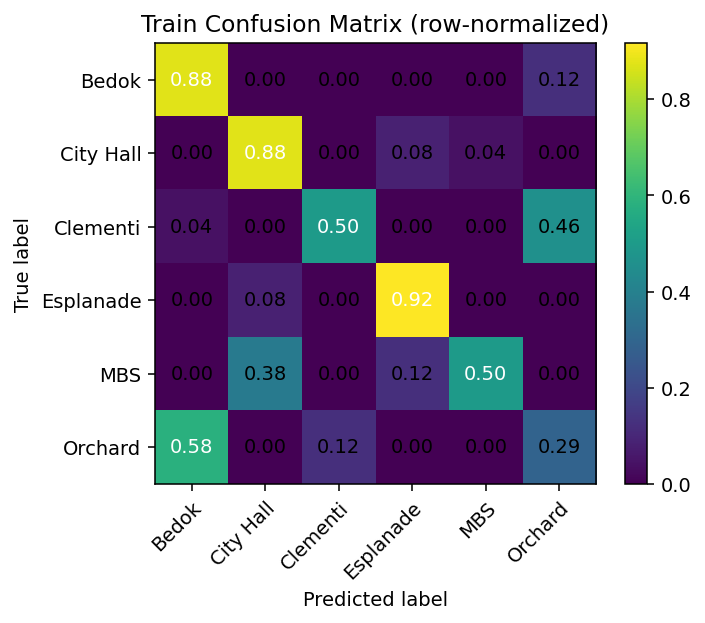


=== VAL ===
Accuracy: 0.7778
              precision    recall  f1-score   support

       Bedok     0.6667    0.6667    0.6667         3
   City Hall     1.0000    1.0000    1.0000         3
    Clementi     0.6667    0.6667    0.6667         3
   Esplanade     1.0000    1.0000    1.0000         3
         MBS     1.0000    1.0000    1.0000         3
     Orchard     0.3333    0.3333    0.3333         3

    accuracy                         0.7778        18
   macro avg     0.7778    0.7778    0.7778        18
weighted avg     0.7778    0.7778    0.7778        18



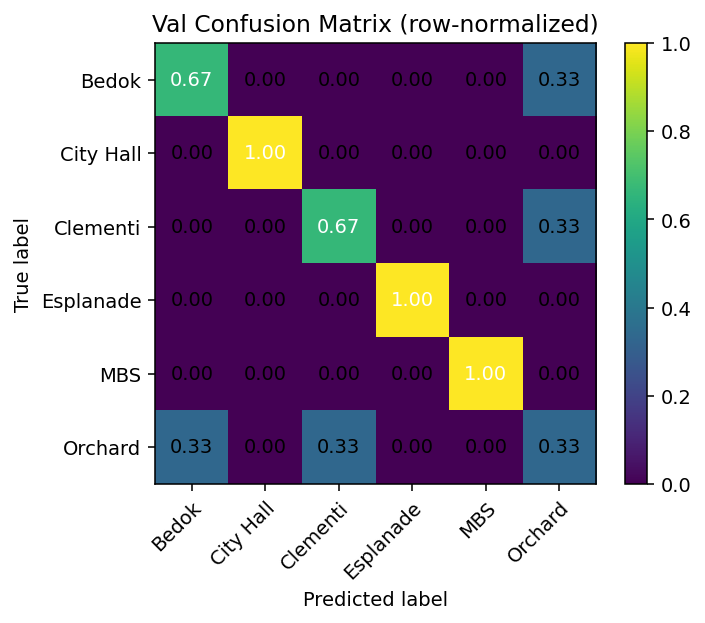


=== TEST ===
Accuracy: 0.8333
              precision    recall  f1-score   support

       Bedok     0.6000    1.0000    0.7500         3
   City Hall     0.7500    1.0000    0.8571         3
    Clementi     1.0000    1.0000    1.0000         3
   Esplanade     1.0000    1.0000    1.0000         3
         MBS     1.0000    0.6667    0.8000         3
     Orchard     1.0000    0.3333    0.5000         3

    accuracy                         0.8333        18
   macro avg     0.8917    0.8333    0.8179        18
weighted avg     0.8917    0.8333    0.8179        18



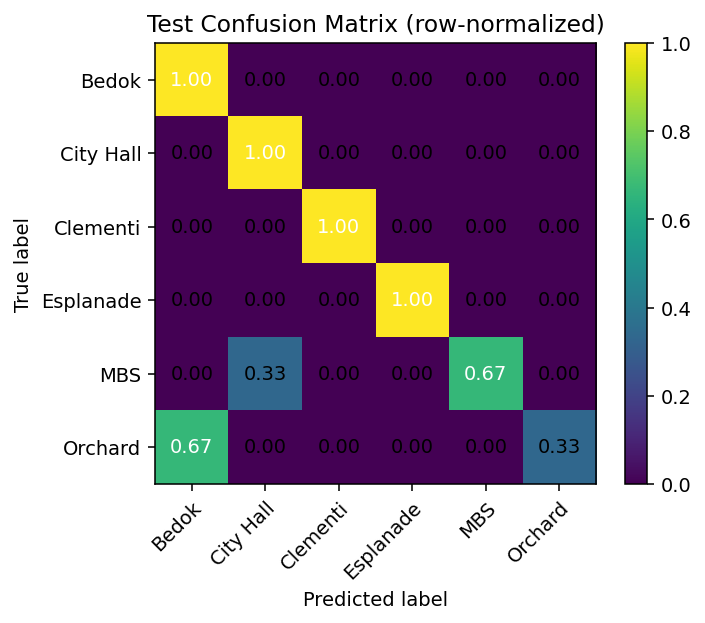


Saved CSV and PNG confusion matrices under: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 2/Project/sign-lang/artifacts


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, roc_auc_score
)

ARTIFACTS = Path("artifacts_6_classes")
MODEL_PATH = ARTIFACTS / "action_lstm.keras"

# --- Load best model ---
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"{MODEL_PATH} not found. Train in Section 7 first.")
model = tf.keras.models.load_model(str(MODEL_PATH))

# --- Ensure datasets are available (from memory or disk) ---
def load_split(name):
    varX, vary = f"X_{name}", f"y_{name}"
    if varX in globals() and vary in globals():
        return globals()[varX], globals()[vary]
    data = np.load(ARTIFACTS / f"dataset_{name}.npz")
    return data["X"], data["y"]

X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")

# Class names
if "classes" in globals():
    class_names = list(classes)
else:
    class_names = [f"class_{i}" for i in range(y_train.shape[1])]
num_classes = len(class_names)

def evaluate_split(X, y, split_name: str):
    """Predict, print metrics, save confusion matrices (raw & normalized), and plot."""
    # Predict
    probs = model.predict(X.astype(np.float32), verbose=0)          # (N, C)
    y_pred = probs.argmax(axis=1)
    y_true = y.argmax(axis=1)

    # Accuracy & report
    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== {split_name.upper()} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion matrices
    labels = np.arange(num_classes)
    cm = confusion_matrix(y_true, y_pred, labels=labels)            # raw counts
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)  # row-normalized

    # Save CSVs
    np.savetxt(ARTIFACTS / f"{split_name}_cm.csv", cm, fmt="%d", delimiter=",")
    np.savetxt(ARTIFACTS / f"{split_name}_cm_norm.csv", cm_norm, fmt="%.6f", delimiter=",")

    # Plot normalized confusion matrix
    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=140)
    im = ax.imshow(cm_norm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(num_classes), yticks=np.arange(num_classes),
        xticklabels=class_names, yticklabels=class_names,
        ylabel="True label", xlabel="Predicted label",
        title=f"{split_name.title()} Confusion Matrix (row-normalized)"
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Annotate cells
    thresh = np.nanmax(cm_norm) / 2.0 if np.isfinite(cm_norm).any() else 0.5
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_norm[i, j] if np.isfinite(cm_norm[i, j]) else 0.0
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > thresh else "black")
    fig.tight_layout()
    out_png = ARTIFACTS / f"{split_name}_cm.png"
    fig.savefig(out_png, bbox_inches="tight")
    plt.show()

    # Binary ROC-AUC (optional, only if 2 classes)
    if num_classes == 2:
        try:
            auc = roc_auc_score(y_true, probs[:, 1])
            print(f"ROC-AUC: {auc:.4f}")
        except Exception as e:
            print(f"[WARN] ROC-AUC skipped: {e}")

    return acc, cm, cm_norm

# Evaluate all splits
train_acc, train_cm, train_cm_norm = evaluate_split(X_train, y_train, "train")
val_acc,   val_cm,   val_cm_norm   = evaluate_split(X_val,   y_val,   "val")
test_acc,  test_cm,  test_cm_norm  = evaluate_split(X_test,  y_test,  "test")

print("\nSaved CSV and PNG confusion matrices under:", ARTIFACTS.resolve())
